# Lecture 3 — Class Exercise
## Line Charts & Slopegraphs: CO2 Emissions

> **Push to:** `week03/lecture03_exercise.ipynb` in your GitHub repo

### Remember:
1. No spaghetti — multiple lines must use grey + single highlight
2. Remove clutter: no chart borders, no heavy gridlines, no legend if you can label directly
3. Insight title — states the finding, not the topic
4. Carry forward from Lecture 2: white background, Arial font, professional quality


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Dataset: CO2 Emissions by Country 2000-2022
# Source: Our World in Data (https://ourworldindata.org/co2-emissions)
df = pd.read_csv('../data/co2_emissions.csv')
print(f"Loaded: {len(df)} rows | Countries: {df['Country'].nunique()} | Years: {df['Year'].min()}-{df['Year'].max()}")
print(df.head())


Loaded: 345 rows | Countries: 15 | Years: 2000-2022
         Country         Region  Year  CO2_Mt  CO2_per_capita
0  United States  North America  2000  5857.6            1.32
1  United States  North America  2001  5724.0            1.26
2  United States  North America  2002  5652.8            1.11
3  United States  North America  2003  5592.8            1.29
4  United States  North America  2004  5743.2            1.12


In [2]:
# Explore before building

print("Countries:", df['Country'].unique())
print("\nCO2 range:", df['CO2_Mt'].min(), "to", df['CO2_Mt'].max(), "Mt")
print("\nRegional averages (2022):")
print(df[df['Year']==2022].groupby('Region')['CO2_Mt'].mean().sort_values(ascending=False).round(1))


Countries: ['United States' 'China' 'India' 'Germany' 'United Kingdom' 'France'
 'Brazil' 'Japan' 'Canada' 'Australia' 'South Korea' 'Russia'
 'South Africa' 'Mexico' 'Indonesia']

CO2 range: 125.3 to 12409.5 Mt

Regional averages (2022):
Region
Asia             3531.1
North America    2393.8
Latin America     629.2
Africa            534.4
Europe            496.5
Oceania           493.7
Name: CO2_Mt, dtype: float64


---
## Task 1 — Multi-Series Line Chart with Highlight

**What to build:** A line chart showing CO2 emissions over time for **all Asian countries** in the dataset, with one country highlighted.

**Requirements:**
- All countries shown (for context), but only **one highlighted in colour** — your choice which
- All other lines in grey (#DDDDDD), thinner
- Highlighted country **labelled directly** at the end of its line (not in a legend)
- Insight title that names the highlighted country and its story

> 💡 `df[df['Region'] == 'Asia']` to filter; use `go.Figure()` with a loop for per-country control


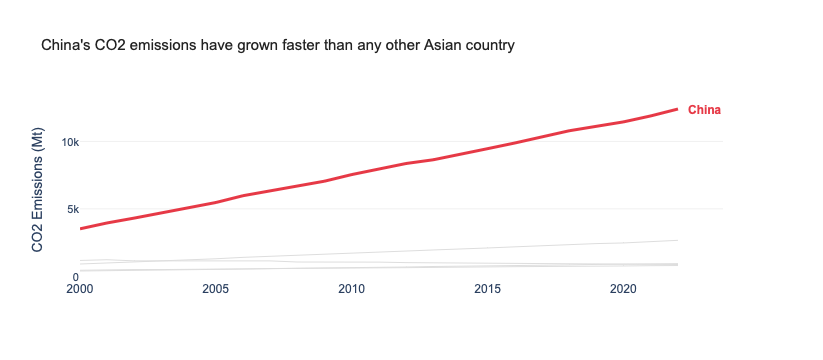

In [6]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv('../data/co2_emissions.csv')

# Filter to Asia
asia = df[df['Region'] == 'Asia']
countries = asia['Country'].unique()

# Pick your highlight country (e.g. China — biggest story)
HIGHLIGHT = 'China'
HIGHLIGHT_COLOR = '#E63946'

fig = go.Figure()

# Loop: grey lines for all others
for country in countries:
    cdf = asia[asia['Country'] == country]
    if country == HIGHLIGHT:
        continue  # draw highlighted line last (on top)
    fig.add_trace(go.Scatter(
        x=cdf['Year'], y=cdf['CO2_Mt'],
        mode='lines',
        line=dict(color='#DDDDDD', width=1),
        showlegend=False,
        hoverinfo='skip'
    ))

# Highlighted line on top
hdf = asia[asia['Country'] == HIGHLIGHT]
last = hdf[hdf['Year'] == hdf['Year'].max()].iloc[0]

fig.add_trace(go.Scatter(
    x=hdf['Year'], y=hdf['CO2_Mt'],
    mode='lines',
    line=dict(color=HIGHLIGHT_COLOR, width=3),
    showlegend=False,
    name=HIGHLIGHT
))

# Direct label at line end
fig.add_annotation(
    x=last['Year'], y=last['CO2_Mt'],
    text=f"<b>{HIGHLIGHT}</b>",
    showarrow=False,
    xanchor='left', xshift=8,
    font=dict(color=HIGHLIGHT_COLOR, size=12, family='Arial')
)

fig.update_layout(
    title=dict(
        text="China's CO2 emissions have grown faster than any other Asian country",
        font=dict(family='Arial', size=15, color='#222222')
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial'),
    xaxis=dict(
        showgrid=False,
        showline=False,
        title=None
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='#F0F0F0',
        showline=False,
        title='CO2 Emissions (Mt)',
        tickfont=dict(family='Arial', size=11)
    ),
    margin=dict(r=100)  # room for end label
)

fig.show()


---
## Task 2 — Slopegraph: Regional Change 2000 vs 2022

**What to build:** A slopegraph comparing **average regional CO2 emissions** between 2000 and 2022.

**Requirements:**
- One line per region (not per country — aggregate first)
- Colour: regions that increased = one colour; decreased = another
- Values labelled at both ends of each line
- No y-axis tick labels (the endpoint labels make them redundant)
- Insight title stating which regions moved most

> 💡 `df.groupby(['Region','Year'])['CO2_Mt'].mean().reset_index()` then filter to 2000 and 2022


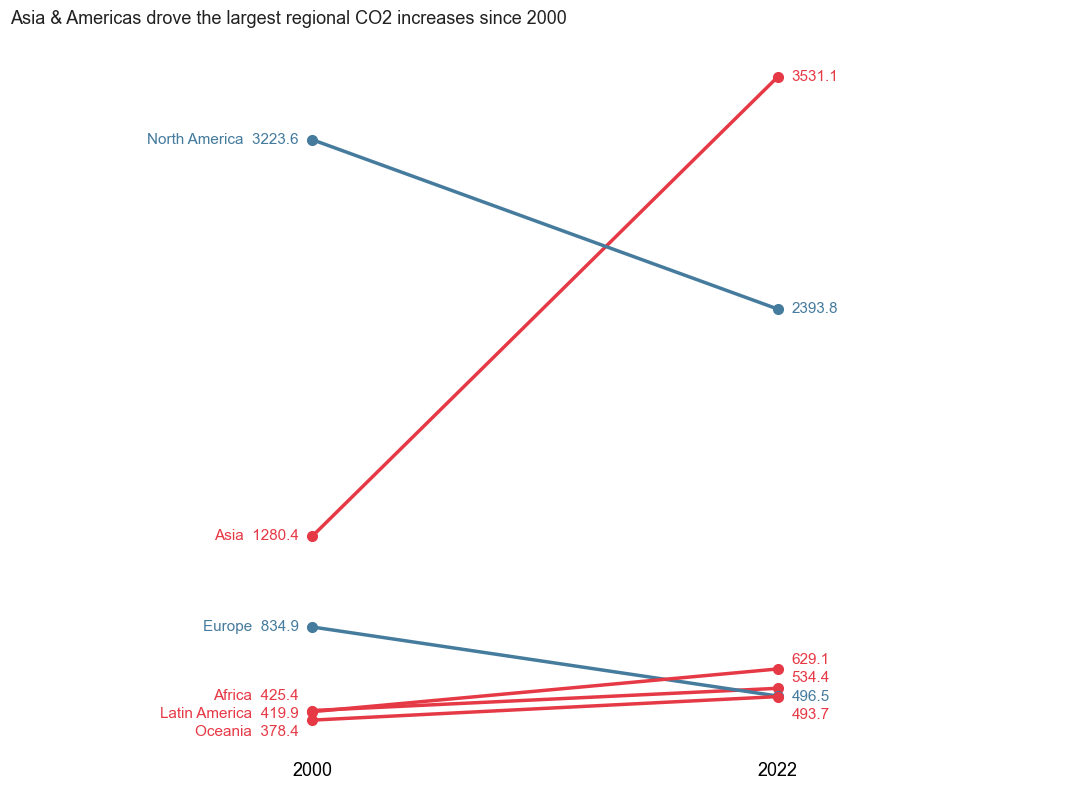

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Aggregate
regional = (
    df.groupby(['Region', 'Year'])['CO2_Mt']
    .mean()
    .reset_index()
)

slope = regional[regional['Year'].isin([2000, 2022])]
pivot = slope.pivot(index='Region', columns='Year', values='CO2_Mt').dropna()
pivot['change'] = pivot[2022] - pivot[2000]
pivot = pivot.reset_index()

INCREASE_COLOR = '#E63946'
DECREASE_COLOR = '#457B9D'

def fix_overlaps(regions_vals, min_gap=80):
    """
    Takes [(region, real_y_value), ...], returns {region: label_y}
    Pushes labels apart while keeping them close to real values.
    """
    sorted_rv = sorted(regions_vals, key=lambda x: x[1])
    labels = {r: v for r, v in sorted_rv}
    
    changed = True
    while changed:
        changed = False
        keys = sorted(labels, key=lambda r: labels[r])
        for i in range(1, len(keys)):
            r0, r1 = keys[i-1], keys[i]
            if labels[r1] - labels[r0] < min_gap:
                mid = (labels[r0] + labels[r1]) / 2
                labels[r0] = mid - min_gap / 2
                labels[r1] = mid + min_gap / 2
                changed = True
    return labels

# Build label positions
left_pairs  = [(row['Region'], row[2000]) for _, row in pivot.iterrows()]
right_pairs = [(row['Region'], row[2022]) for _, row in pivot.iterrows()]

left_label_y  = fix_overlaps(left_pairs,  min_gap=90)
right_label_y = fix_overlaps(right_pairs, min_gap=90)

fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for _, row in pivot.iterrows():
    color = INCREASE_COLOR if row['change'] > 0 else DECREASE_COLOR
    region = row['Region']

    # Line uses REAL data values
    ax.plot([0, 1], [row[2000], row[2022]],
            color=color, linewidth=2.5,
            marker='o', markersize=7, zorder=3)

    # Left label at fixed-overlap position
    ax.text(-0.03, left_label_y[region],
            f"{region}  {row[2000]:.1f}",
            ha='right', va='center',
            color=color, fontsize=11, fontfamily='Arial')

    # Right label at fixed-overlap position
    ax.text(1.03, right_label_y[region],
            f"{row[2022]:.1f}",
            ha='left', va='center',
            color=color, fontsize=11, fontfamily='Arial')

ax.set_xlim(-0.65, 1.65)
ax.set_xticks([0, 1])
ax.set_xticklabels(['2000', '2022'], fontsize=13, fontfamily='Arial')
ax.yaxis.set_visible(False)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(bottom=False)

ax.set_title(
    "Asia & Americas drove the largest regional CO2 increases since 2000",
    fontsize=13, fontfamily='Arial', color='#222222',
    loc='left', pad=15
)

plt.tight_layout()
plt.show()